In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('metrics_pods_view_202410310113.csv.zip')

In [4]:
df.head()

,node,pod,time,container_blkio_device_usage_total_value,container_cpu_cfs_periods_total_value,container_cpu_cfs_throttled_periods_total_value,container_cpu_cfs_throttled_seconds_total_value,container_cpu_load_average_10s_value,container_cpu_system_seconds_total_value,container_cpu_usage_seconds_total_value,...,container_tasks_state_value,container_threads_value,container_threads_max_value,container_ulimits_soft_value,kube_pod_container_status_restarts_total_value,phase,phasetime,cpu,memory,utiltime
0,node1,autoscaler-55bdcd9565-ld2gm,2024-10-20 22:45:27.000 +0200,9072640.0,53042.0,0.0,0.000000,0.0,7.97,46.646560,...,0.0,7.0,0.0,1048576.0,NaN,NaN,NaN,NaN,NaN,NaN
1,node1,istiod-64ddd8d77-g84cs,2024-10-20 22:45:28.000 +0200,NaN,NaN,NaN,NaN,0.0,0.01,0.039836,...,0.0,1.0,0.0,1048576.0,NaN,NaN,NaN,NaN,NaN,NaN
2,node1,webhook-8c895dd9f-77wqv,2024-10-20 22:45:28.000 +0200,9281536.0,28014.0,0.0,0.000000,0.0,6.31,36.118737,...,0.0,7.0,0.0,1048576.0,NaN,NaN,NaN,NaN,NaN,NaN
3,node1,ebs-csi-controller-f64c4595d-tlf6l,2024-10-20 22:45:29.000 +0200,4792320.0,NaN,NaN,NaN,0.0,0.35,4.414272,...,0.0,7.0,0.0,1048576.0,NaN,NaN,NaN,NaN,NaN,NaN
4,node1,neo4j-0,2024-10-20 22:45:30.000 +0200,19723776.0,60353.0,707.0,116.906619,0.0,11.28,80.619003,...,0.0,55.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223116 entries, 0 to 223115
Data columns (total 54 columns):
 #   Column                                                  Non-Null Count   Dtype  
---  ------                                                  --------------   -----  
 0   node                                                    223116 non-null  object 
 1   pod                                                     223116 non-null  object 
 2   time                                                    223116 non-null  object 
 3   container_blkio_device_usage_total_value                103393 non-null  float64
 4   container_cpu_cfs_periods_total_value                   14137 non-null   float64
 5   container_cpu_cfs_throttled_periods_total_value         14137 non-null   float64
 6   container_cpu_cfs_throttled_seconds_total_value         14137 non-null   float64
 7   container_cpu_load_average_10s_value                    139995 non-null  float64
 8   container_cpu_system_sec

In [5]:
df = df.drop(columns=['node','pod','time'])

In [6]:
df = df.drop(columns=['utiltime'])

In [7]:
df = df.dropna(subset=['phase'])

In [8]:
df = df.drop(columns=['phasetime'])

In [10]:
df['phase'].value_counts()

,count
phase,
Running,219977
Pending,1804
Failed,1150


In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['phase'])

In [16]:
X = df.drop(columns=['phase'])

In [26]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 222931 entries, 157 to 223115
Data columns (total 48 columns):
 #   Column                                                  Non-Null Count   Dtype  
---  ------                                                  --------------   -----  
 0   container_blkio_device_usage_total_value                103306 non-null  float64
 1   container_cpu_cfs_periods_total_value                   14114 non-null   float64
 2   container_cpu_cfs_throttled_periods_total_value         14114 non-null   float64
 3   container_cpu_cfs_throttled_seconds_total_value         14114 non-null   float64
 4   container_cpu_load_average_10s_value                    139866 non-null  float64
 5   container_cpu_system_seconds_total_value                139866 non-null  float64
 6   container_cpu_usage_seconds_total_value                 139265 non-null  float64
 7   container_cpu_user_seconds_total_value                  139866 non-null  float64
 8   container_file_descriptors_

In [17]:
X_filtered_soft = X.drop(columns=X.columns[X.count()<110000])

In [28]:
X_filtered_soft.info()

<class 'pandas.core.frame.DataFrame'>
Index: 222931 entries, 157 to 223115
Data columns (total 22 columns):
 #   Column                                    Non-Null Count   Dtype  
---  ------                                    --------------   -----  
 0   container_cpu_load_average_10s_value      139866 non-null  float64
 1   container_cpu_system_seconds_total_value  139866 non-null  float64
 2   container_cpu_usage_seconds_total_value   139265 non-null  float64
 3   container_cpu_user_seconds_total_value    139866 non-null  float64
 4   container_file_descriptors_value          139866 non-null  float64
 5   container_memory_cache_value              139866 non-null  float64
 6   container_memory_failcnt_value            139866 non-null  float64
 7   container_memory_failures_total_value     139927 non-null  float64
 8   container_memory_mapped_file_value        139835 non-null  float64
 9   container_memory_max_usage_bytes_value    139736 non-null  float64
 10  container_memory_rss_va

In [18]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
X_filtered_soft_imputed = pd.DataFrame(imputer.fit_transform(X_filtered_soft),columns=X_filtered_soft.columns)

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, cross_val_score

scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(X_filtered_soft_imputed,y,test_size=0.1)
fitted = scaler.fit(X_train)
X_train_scaled = fitted.transform(X_train)
X_test_scaled = fitted.transform(X_test)

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import xgboost as xgb
from sklearn.linear_model import LogisticRegression

models = []
models.append(('LR', LogisticRegression(solver='liblinear', multi_class='ovr')))
models.append(('KNN', KNeighborsClassifier()))
models.append(('SVM', SVC()))
models.append(('XGB', xgb.XGBClassifier()))
models.append(('RF', RandomForestClassifier()))
scoring = {'acc': 'accuracy',
           'f1': 'f1_macro'}
results_acc = []
results_f1 = []
names = []
for name, model in models:
    kfold = StratifiedKFold(n_splits=5, random_state=1, shuffle=True)
    cv_results = cross_validate(model, X_train_scaled, y_train, cv=kfold, scoring=scoring)
    results_acc.append(cv_results['test_acc'])
    results_f1.append(cv_results['test_f1'])
    names.append(name)
    print('%s acc: %f (%f), f1: %f (%f)' % (name, cv_results['test_acc'].mean(), cv_results['test_acc'].std(),cv_results['test_f1'].mean(), cv_results['test_f1'].std()))

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, i

LR acc: 0.986623 (0.000010), f1: 0.331089 (0.000002)
KNN acc: 0.997523 (0.000564), f1: 0.894300 (0.035686)
SVM acc: 0.989299 (0.000192), f1: 0.496064 (0.008660)
XGB acc: 0.998151 (0.000171), f1: 0.926991 (0.005752)
RF acc: 0.998226 (0.000213), f1: 0.929372 (0.006977)


<ipython-input-22-bb65af361542>:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results_acc, labels=names)


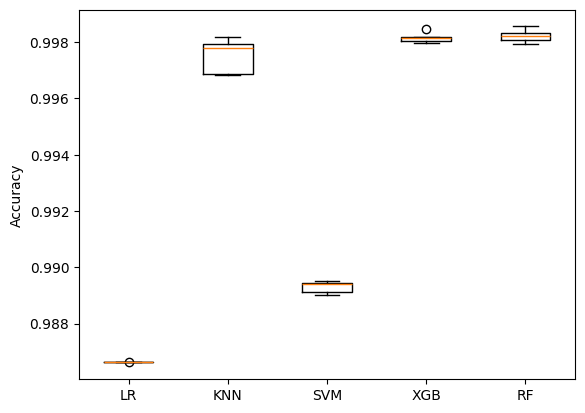

<ipython-input-22-bb65af361542>:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results_f1, labels=names)


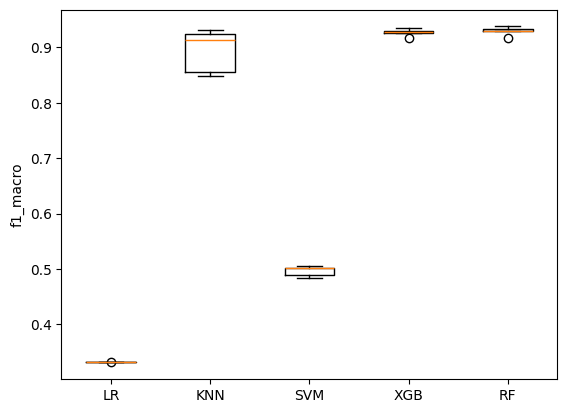

In [22]:
import matplotlib.pyplot as plt

plt.boxplot(results_acc, labels=names)
#plt.title('Algorithm Comparison')
plt.ylabel('Accuracy')
plt.show()
plt.boxplot(results_f1, labels=names)
#plt.title('Algorithm Comparison')
plt.ylabel('f1_macro')
plt.show()

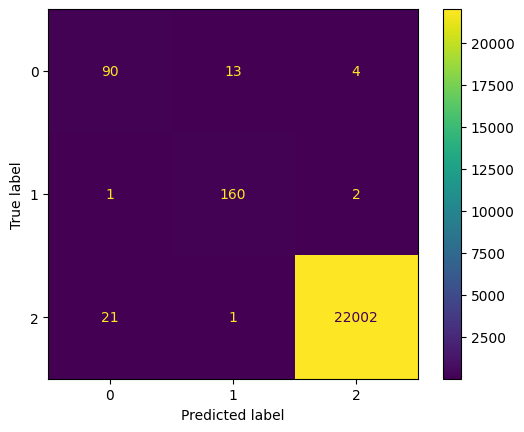

              precision    recall  f1-score   support

           0       0.80      0.84      0.82       107
           1       0.92      0.98      0.95       163
           2       1.00      1.00      1.00     22024

    accuracy                           1.00     22294
   macro avg       0.91      0.94      0.92     22294
weighted avg       1.00      1.00      1.00     22294



In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, f1_score

model = xgb.XGBClassifier()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()
print(classification_report(y_test, y_pred))

In [25]:
def ensemble_predictions(members, testX):
    yhats = [model.predict(testX) for model in members]
    yhats = np.array(yhats)
    mode = [Counter(col).most_common(1)[0][0] for col in zip(*yhats)]
    return mode

In [26]:
def evaluate_model(trainX, trainy, train_idx):
    clf = xgb.XGBClassifier()
    model = clf.fit(trainX[train_idx][0], trainy[train_idx])
    return model

In [27]:
def evaluate_n_members(members, n_members, testX, testy):
    subset = members[:n_members]
    yhat = ensemble_predictions(subset, testX)
    return yhat, accuracy_score(testy, yhat), f1_score(testy, yhat, average='macro')

In [29]:
from sklearn.utils import resample

n_splits = 100
scores, members = list(), list()
ix = [i for i in range(len(X_train_scaled))]
for j in range(n_splits):
    train_ix = [resample(ix, replace=True, n_samples=len(X_train_scaled))]
    model = evaluate_model(X_train_scaled, y_train, train_ix)
    members.append(model)

In [31]:
from collections import Counter

single_accs, ensemble_accs, single_f1s, ensemble_f1s = list(), list(), list(), list()
for i in range(1, n_splits+1):
    _, ensemble_acc, ensemble_f1 = evaluate_n_members(members, i, X_test_scaled, y_test)
    single_acc = accuracy_score(members[i-1].predict(X_test_scaled), y_test)
    single_f1 = f1_score(members[i-1].predict(X_test_scaled), y_test, average='macro')
    print('> %d: single_acc=%f, ensemble_acc=%f' % (i, single_acc, ensemble_acc))
    print('> %d: single_f1=%f, ensemble_f1=%f' % (i, single_f1, ensemble_f1))
    ensemble_accs.append(ensemble_acc)
    single_accs.append(single_acc)
    ensemble_f1s.append(ensemble_f1)
    single_f1s.append(single_f1)

> 1: single_acc=0.998251, ensemble_acc=0.998251
> 1: single_f1=0.926573, ensemble_f1=0.926573
> 2: single_acc=0.998071, ensemble_acc=0.998251
> 2: single_f1=0.922121, ensemble_f1=0.926573
> 3: single_acc=0.998161, ensemble_acc=0.998206
> 3: single_f1=0.924877, ensemble_f1=0.925624
> 4: single_acc=0.998251, ensemble_acc=0.998206
> 4: single_f1=0.926921, ensemble_f1=0.925624
> 5: single_acc=0.998116, ensemble_acc=0.998251
> 5: single_f1=0.923065, ensemble_f1=0.926921
> 6: single_acc=0.998296, ensemble_acc=0.998251
> 6: single_f1=0.928740, ensemble_f1=0.926921
> 7: single_acc=0.998161, ensemble_acc=0.998251
> 7: single_f1=0.924339, ensemble_f1=0.926921
> 8: single_acc=0.998026, ensemble_acc=0.998251
> 8: single_f1=0.920859, ensemble_f1=0.926921
> 9: single_acc=0.998026, ensemble_acc=0.998206
> 9: single_f1=0.920264, ensemble_f1=0.925624
> 10: single_acc=0.997982, ensemble_acc=0.998206
> 10: single_f1=0.919314, ensemble_f1=0.925624
> 11: single_acc=0.998116, ensemble_acc=0.998116
> 11: sin

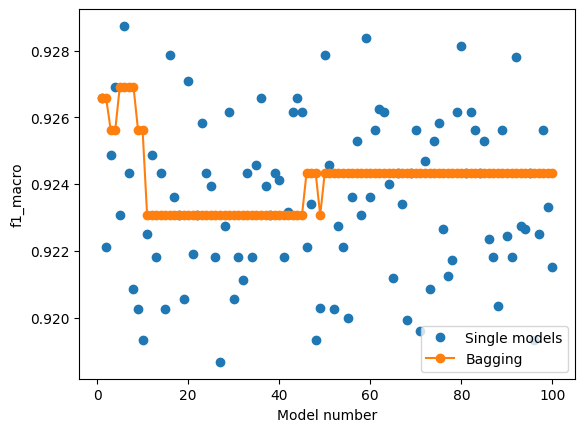

In [32]:
x_axis = [i for i in range(1, n_splits+1)]
plt.plot(x_axis, single_f1s, marker='o', linestyle='None')
plt.plot(x_axis, ensemble_f1s, marker='o')
plt.xlabel('Model number')
plt.ylabel('f1_macro')
plt.legend(['Single models','Bagging'])

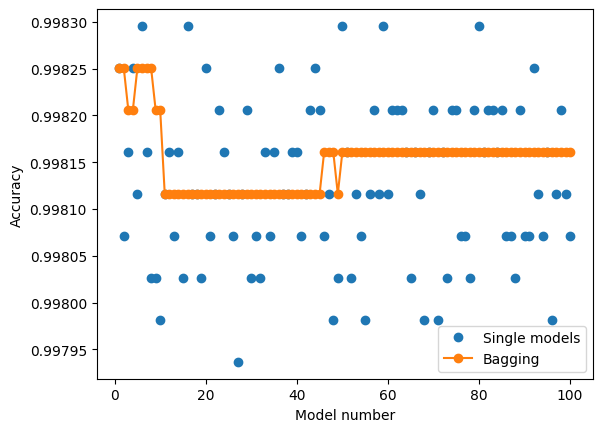

In [33]:
x_axis = [i for i in range(1, n_splits+1)]
plt.plot(x_axis, single_accs, marker='o', linestyle='None')
plt.plot(x_axis, ensemble_accs, marker='o')
plt.xlabel('Model number')
plt.ylabel('Accuracy')
plt.legend(['Single models','Bagging'])

In [36]:
import shap

In [37]:
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_filtered_soft_imputed.columns)
explainer = shap.Explainer(model.predict, X_test_scaled_df)

In [40]:
shap_values = explainer(X_test_scaled_df.sample(n=2000))

PermutationExplainer explainer: 2001it [12:45,  2.59it/s]


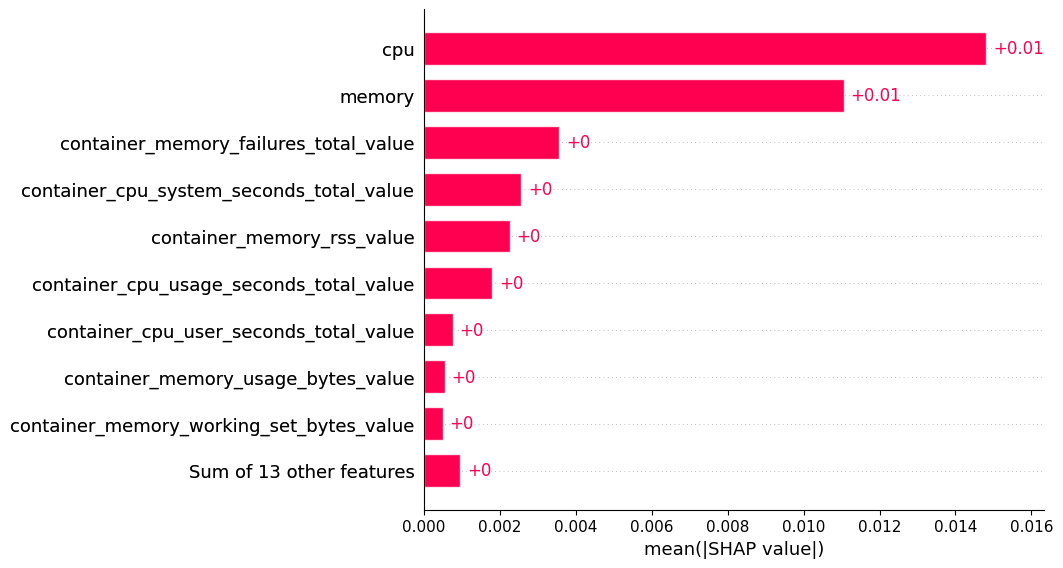

In [41]:
shap.plots.bar(shap_values)

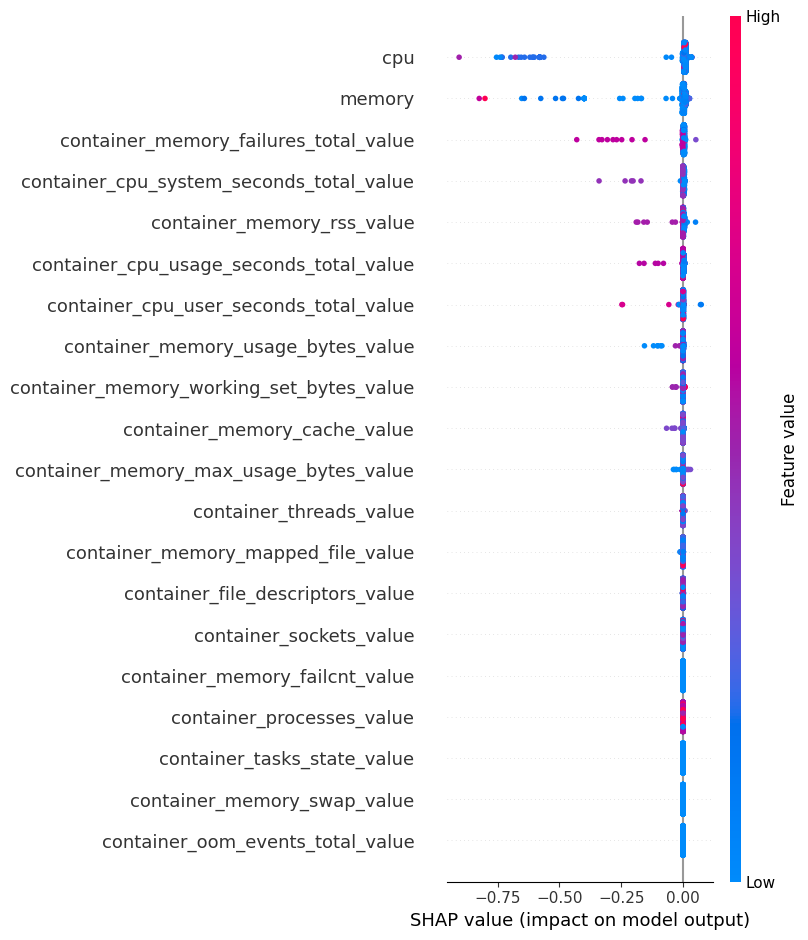

In [42]:
shap.summary_plot(shap_values)

In [43]:
def print_feature_importances_shap_values(shap_values, features):
    importances = []
    for i in range(shap_values.values.shape[1]):
        importances.append(np.mean(np.abs(shap_values.values[:, i])))
    importances_norm = softmax(importances)
    feature_importances = {fea: imp for imp, fea in zip(importances, features)}
    feature_importances_norm = {fea: imp for imp, fea in zip(importances_norm, features)}
    feature_importances = {k: v for k, v in sorted(feature_importances.items(), key=lambda item: item[1], reverse = True)}
    feature_importances_norm= {k: v for k, v in sorted(feature_importances_norm.items(), key=lambda item: item[1], reverse = True)}
    for k, v in feature_importances.items():
        print(f"{k} -> {v:.4f} (softmax = {feature_importances_norm[k]:.4f})")

In [45]:
from scipy.special import softmax

features = X_filtered_soft_imputed.columns
print_feature_importances_shap_values(shap_values, features)

cpu -> 0.0148 (softmax = 0.0461)
memory -> 0.0111 (softmax = 0.0459)
container_memory_failures_total_value -> 0.0036 (softmax = 0.0455)
container_cpu_system_seconds_total_value -> 0.0026 (softmax = 0.0455)
container_memory_rss_value -> 0.0023 (softmax = 0.0455)
container_cpu_usage_seconds_total_value -> 0.0018 (softmax = 0.0455)
container_cpu_user_seconds_total_value -> 0.0008 (softmax = 0.0454)
container_memory_usage_bytes_value -> 0.0006 (softmax = 0.0454)
container_memory_working_set_bytes_value -> 0.0005 (softmax = 0.0454)
container_memory_cache_value -> 0.0004 (softmax = 0.0454)
container_memory_max_usage_bytes_value -> 0.0003 (softmax = 0.0454)
container_threads_value -> 0.0001 (softmax = 0.0454)
container_memory_mapped_file_value -> 0.0001 (softmax = 0.0454)
container_file_descriptors_value -> 0.0000 (softmax = 0.0454)
container_sockets_value -> 0.0000 (softmax = 0.0454)
container_cpu_load_average_10s_value -> 0.0000 (softmax = 0.0454)
container_memory_failcnt_value -> 0.0000 (s